# Model Versioning & Drift Detection

**Module**: Production & Deployment | **Notebook 05**  
**Level**: Intermediate  
**Duration**: 45-60 minutes

---

## Learning Objectives

1. Use `ModelRegistry` to version models over time
2. Register, list, and load model versions
3. Compare parameters across versions to detect drift
4. Implement a simple monitoring workflow
5. Delete outdated versions and manage storage

## Prerequisites

- Completed Notebooks 01-04 (Predict, Save/Load, Pipeline, Validation)
- Familiarity with `PanelPipeline` (Notebook 03)
- Basic understanding of model deployment concepts

## Setup

In [1]:
# Standard libraries
import shutil
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

warnings.filterwarnings("ignore")

# PanelBox imports
# Tutorial utilities
import sys

from panelbox.gmm import DifferenceGMM
from panelbox.models.static.pooled_ols import PooledOLS
from panelbox.production import ModelRegistry, PanelPipeline

sys.path.insert(0, str(Path("..").resolve()))
from utils import plot_coefficient_drift, set_production_style

# Visualization configuration
set_production_style()
sns.set_palette("husl")
pd.set_option("display.max_columns", None)
pd.set_option("display.precision", 4)

# Reproducibility
np.random.seed(42)

# Paths
BASE_DIR = Path("..")
DATA_DIR = BASE_DIR / "data"
OUTPUT_DIR = BASE_DIR / "outputs"
FIGURES_DIR = OUTPUT_DIR / "figures"
MODELS_DIR = OUTPUT_DIR / "models"
REGISTRY_DIR = OUTPUT_DIR / "registry"

# Create directories
for d in [FIGURES_DIR, MODELS_DIR, REGISTRY_DIR]:
    d.mkdir(parents=True, exist_ok=True)

print("Setup complete!")

Setup complete!


### Load the Datasets

In [2]:
# Firm panel data
df_firms = pd.read_csv(DATA_DIR / "firm_panel.csv")

print("=== Firm Panel ===")
print(f"Shape: {df_firms.shape}")
print(
    f"Firms: {df_firms['firm_id'].nunique()}, Years: {df_firms['year'].min()}-{df_firms['year'].max()}"
)
print(f"Columns: {list(df_firms.columns)}")
print()
df_firms.head(3)

=== Firm Panel ===
Shape: (2000, 7)
Firms: 100, Years: 2000-2019
Columns: ['firm_id', 'year', 'investment', 'value', 'capital', 'sales', 'sector']



,firm_id,year,investment,value,capital,sales,sector
0,1,2000,3.9817,6.8261,5.3317,4.5163,Manufacturing
1,1,2001,4.9167,6.2308,4.9664,7.2299,Manufacturing
2,1,2002,4.1953,4.6224,4.8215,5.7497,Manufacturing


In [3]:
# Bank LGD data
df_lgd = pd.read_csv(DATA_DIR / "bank_lgd.csv")

print("=== Bank LGD Panel ===")
print(f"Shape: {df_lgd.shape}")
print(
    f"Contracts: {df_lgd['contract_id'].nunique()}, Months: {df_lgd['month'].min()}-{df_lgd['month'].max()}"
)
print(f"Columns: {list(df_lgd.columns)}")
print()
df_lgd.head(3)

=== Bank LGD Panel ===
Shape: (3000, 7)
Contracts: 200, Months: 1-15
Columns: ['contract_id', 'month', 'lgd_logit', 'saldo_real', 'pib_growth', 'selic', 'collateral_ratio']



,contract_id,month,lgd_logit,saldo_real,pib_growth,selic,collateral_ratio
0,1,1,0.2015,10.1292,2.3588,10.5697,0.5056
1,1,2,1.5349,10.1262,2.3773,9.7553,0.6011
2,1,3,2.0552,10.5844,2.8060,9.7743,0.5831


---

## Section 1: Why Version Models?

In production, models are not static. They need to be **retrained** periodically as new data becomes available. This creates several challenges:

| Challenge | Description | Example |
|---|---|---|
| **Concept drift** | The relationship between features and target changes over time | Economic regime shifts |
| **Data drift** | The distribution of input features changes | New types of firms enter the panel |
| **Audit trail** | Regulators require knowing which model produced which prediction | Banking (Basel III/IV) |
| **Reproducibility** | Need to reproduce past predictions exactly | Regulatory reporting |
| **Rollback** | If a new model performs worse, revert to previous version | Failed refit |

**Model versioning** solves these problems by maintaining a structured history of all model versions, with metadata, timestamps, and the ability to load any past version.

PanelBox provides the `ModelRegistry` class for simple, file-based model versioning.

---

## Section 2: ModelRegistry Basics

The `ModelRegistry` stores model versions in a structured directory:

```
registry_dir/
    registry.json          # Index of all versions
    v1/model.pkl           # Version 1 pipeline
    v1/metadata.json       # Version 1 metadata
    v2/model.pkl           # Version 2 pipeline
    v2/metadata.json       # Version 2 metadata
    ...
```

Key operations:
- `register(pipeline, version, notes)` — Save a fitted pipeline as a new version
- `list_versions()` — List all registered versions with metadata
- `load_version(version)` — Load a specific version
- `load_latest()` — Load the most recently registered version
- `delete_version(version)` — Remove a version

In [4]:
# Clean up any previous registry from prior runs
firm_reg_dir = REGISTRY_DIR / "firm_investment"
if firm_reg_dir.exists():
    shutil.rmtree(firm_reg_dir)

# Create a new registry
registry = ModelRegistry(firm_reg_dir)
print(f"Registry created at: {firm_reg_dir}")
print(f"Current versions: {len(registry.list_versions())}")

Registry created at: ../outputs/registry/firm_investment
Current versions: 0


### Train and Register Version 1 (2000-2015 data)

In [5]:
# Split firm data by year
df_train_2015 = df_firms[df_firms["year"] <= 2015].copy()
df_train_2017 = df_firms[df_firms["year"] <= 2017].copy()
df_train_2019 = df_firms.copy()  # All years (2000-2019)

print(
    f"Training set v1 (2000-2015): {df_train_2015.shape[0]} obs, {df_train_2015['firm_id'].nunique()} firms"
)
print(
    f"Training set v2 (2000-2017): {df_train_2017.shape[0]} obs, {df_train_2017['firm_id'].nunique()} firms"
)
print(
    f"Training set v3 (2000-2019): {df_train_2019.shape[0]} obs, {df_train_2019['firm_id'].nunique()} firms"
)

Training set v1 (2000-2015): 1600 obs, 100 firms
Training set v2 (2000-2017): 1800 obs, 100 firms
Training set v3 (2000-2019): 2000 obs, 100 firms


In [6]:
# Train v1: PooledOLS on 2000-2015
pipeline_v1 = PanelPipeline(
    model_class=PooledOLS,
    model_params={
        "formula": "investment ~ value + capital + sales",
        "entity_col": "firm_id",
        "time_col": "year",
    },
    name="Firm Investment OLS",
    description="PooledOLS model for firm investment",
)
pipeline_v1.fit(df_train_2015)

# Register v1
version_name = registry.register(pipeline_v1, version="v1", notes="Initial model on 2000-2015 data")
print(f"Registered: {version_name}")
print("Coefficients:")
print(pipeline_v1.results.params)

Registered: v1
Coefficients:
Intercept   -0.5838
value        0.3028
capital      0.2862
sales        0.1693
dtype: float64


### Train and Register Version 2 (2000-2017 data)

In [7]:
# Train v2: Same specification, more data
pipeline_v2 = PanelPipeline(
    model_class=PooledOLS,
    model_params={
        "formula": "investment ~ value + capital + sales",
        "entity_col": "firm_id",
        "time_col": "year",
    },
    name="Firm Investment OLS",
    description="PooledOLS updated with 2016-2017 data",
)
pipeline_v2.fit(df_train_2017)

# Register v2
version_name = registry.register(pipeline_v2, version="v2", notes="Updated with 2016-2017 data")
print(f"Registered: {version_name}")
print("Coefficients:")
print(pipeline_v2.results.params)

Registered: v2
Coefficients:
Intercept   -0.5261
value        0.2936
capital      0.2823
sales        0.1701
dtype: float64


### List Registered Versions

In [8]:
# List all versions
versions = registry.list_versions()

print(f"Total versions: {len(versions)}")
print()
for v in versions:
    print(f"  {v['version']}: {v['timestamp'][:19]}")
    print(
        f"    Model: {v['model_class']}, Params: {v.get('n_params', 'N/A')}, Obs: {v.get('nobs', 'N/A')}"
    )
    print(f"    Notes: {v['notes']}")
    print()

Total versions: 2

  v1: 2026-02-22T15:55:09
    Model: PooledOLS, Params: 4, Obs: 1600
    Notes: Initial model on 2000-2015 data

  v2: 2026-02-22T15:55:09
    Model: PooledOLS, Params: 4, Obs: 1800
    Notes: Updated with 2016-2017 data



### Load Specific Versions

In [9]:
# Load a specific version
loaded_v1 = registry.load_version("v1")
print(f"Loaded v1: {loaded_v1}")
print(f"v1 coefficients: {loaded_v1.results.params.to_dict()}")
print()

# Load the latest version (should be v2)
loaded_latest = registry.load_latest()
print(f"Loaded latest: {loaded_latest}")
print(f"Latest coefficients: {loaded_latest.results.params.to_dict()}")

Loaded v1: PanelPipeline(name='Firm Investment OLS', model=PooledOLS, fitted)
v1 coefficients: {'Intercept': -0.5838035262681375, 'value': 0.3028235666577428, 'capital': 0.2861545547710391, 'sales': 0.16932735685214806}

Loaded latest: PanelPipeline(name='Firm Investment OLS', model=PooledOLS, fitted)
Latest coefficients: {'Intercept': -0.526138447025083, 'value': 0.29359951605565815, 'capital': 0.28230375954956305, 'sales': 0.17007992401777866}


---

## Section 3: Comparing Versions (Drift Detection)

When a model is retrained on new data, its coefficients may change. The `compare()` method provides a structured way to detect **parameter drift**:

$$\text{pct\_change}_j = \frac{\beta_j^{\text{new}} - \beta_j^{\text{old}}}{|\beta_j^{\text{old}}|} \times 100$$

A large percentage change (e.g., > 10-20%) may indicate:
- The data distribution has shifted
- The model is sensitive to the training window
- A structural break has occurred

In [10]:
# Compare v1 and v2
comparison = loaded_v1.compare(loaded_latest)
print("Coefficient Comparison: v1 vs v2")
print("=" * 60)
print(comparison.to_string(float_format="{:.4f}".format))

Coefficient Comparison: v1 vs v2
           current  previous    diff  pct_change
Intercept  -0.5838   -0.5261 -0.0577    -10.9601
value       0.3028    0.2936  0.0092      3.1417
capital     0.2862    0.2823  0.0039      1.3641
sales       0.1693    0.1701 -0.0008     -0.4425


In [11]:
# Flag significant changes (> 10% drift)
threshold = 10  # percent
significant = comparison[comparison["pct_change"].abs() > threshold]

if len(significant) > 0:
    print(f"WARNING: {len(significant)} parameter(s) drifted more than {threshold}%:")
    print(
        significant[["current", "previous", "pct_change"]].to_string(float_format="{:.4f}".format)
    )
else:
    print(f"All parameters within {threshold}% tolerance. Model is stable.")

           current  previous  pct_change
Intercept  -0.5838   -0.5261    -10.9601


### Visualizing Coefficient Drift

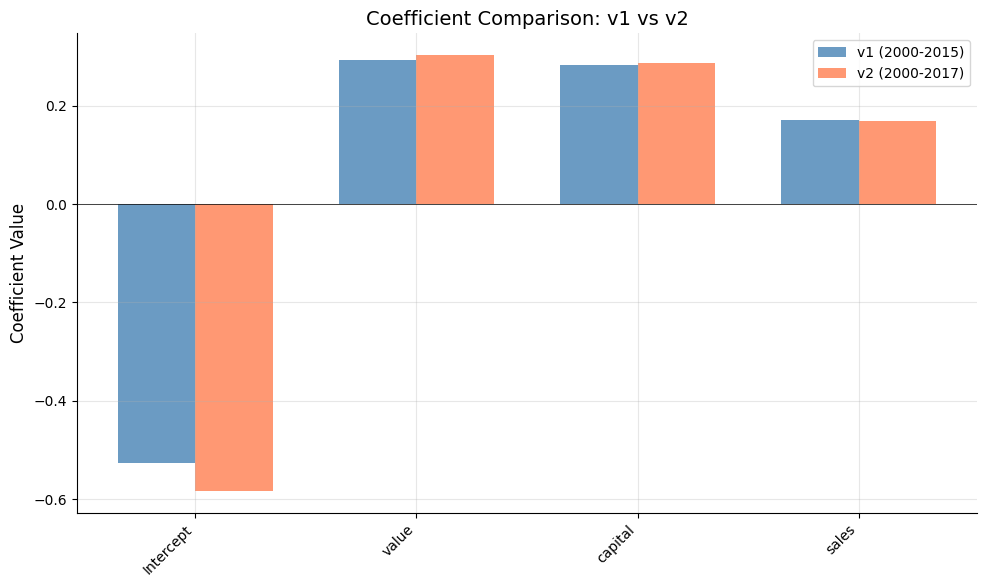

Figure saved.


In [12]:
# Bar chart: v1 vs v2 coefficients side by side
fig, ax = plt.subplots(figsize=(10, 6))

params = comparison.index.tolist()
x = np.arange(len(params))
width = 0.35

bars1 = ax.bar(
    x - width / 2,
    comparison["previous"],
    width,
    label="v1 (2000-2015)",
    color="steelblue",
    alpha=0.8,
)
bars2 = ax.bar(
    x + width / 2, comparison["current"], width, label="v2 (2000-2017)", color="coral", alpha=0.8
)

ax.set_xticks(x)
ax.set_xticklabels(params, rotation=45, ha="right")
ax.set_ylabel("Coefficient Value")
ax.set_title("Coefficient Comparison: v1 vs v2")
ax.legend()
ax.axhline(y=0, color="black", linewidth=0.5)

plt.tight_layout()
plt.savefig(FIGURES_DIR / "05_coefficient_comparison_v1_v2.png", dpi=300, bbox_inches="tight")
plt.show()
print("Figure saved.")

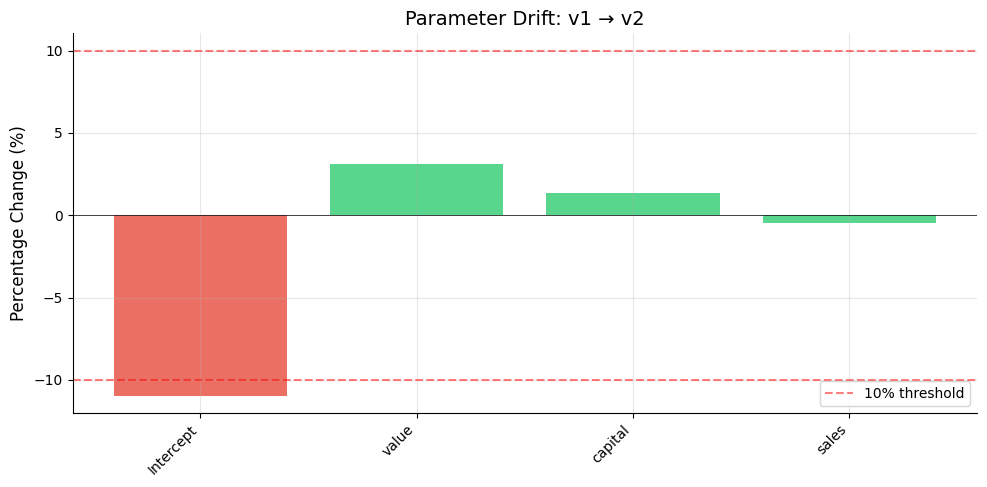

Figure saved.


In [13]:
# Percentage change bar chart
fig, ax = plt.subplots(figsize=(10, 5))

colors = ["#e74c3c" if abs(v) > 10 else "#2ecc71" for v in comparison["pct_change"]]
ax.bar(comparison.index, comparison["pct_change"], color=colors, alpha=0.8)

# Threshold lines
ax.axhline(y=10, color="red", linestyle="--", alpha=0.5, label="10% threshold")
ax.axhline(y=-10, color="red", linestyle="--", alpha=0.5)
ax.axhline(y=0, color="black", linewidth=0.5)

ax.set_ylabel("Percentage Change (%)")
ax.set_title("Parameter Drift: v1 → v2")
ax.legend()
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "05_drift_pct_change.png", dpi=300, bbox_inches="tight")
plt.show()
print("Figure saved.")

### Multi-Version Drift Visualization

Let's add a third version and track coefficients across all versions using the `plot_coefficient_drift` utility.

In [14]:
# Train v3: Full data (2000-2019)
pipeline_v3 = PanelPipeline(
    model_class=PooledOLS,
    model_params={
        "formula": "investment ~ value + capital + sales",
        "entity_col": "firm_id",
        "time_col": "year",
    },
    name="Firm Investment OLS",
    description="PooledOLS with full 2000-2019 data",
)
pipeline_v3.fit(df_train_2019)

registry.register(pipeline_v3, version="v3", notes="Full dataset 2000-2019")

print(f"Total versions: {len(registry.list_versions())}")
print("v3 coefficients:")
print(pipeline_v3.results.params)

Total versions: 3
v3 coefficients:
Intercept   -0.5074
value        0.2990
capital      0.2773
sales        0.1674
dtype: float64


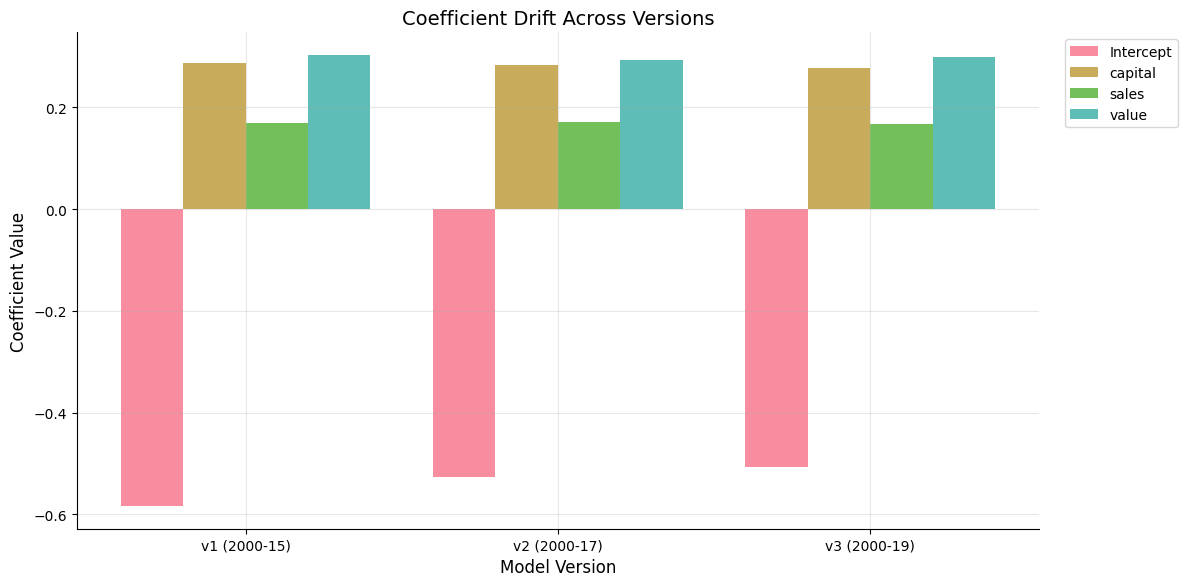

Figure saved.


In [15]:
# Use the plot_coefficient_drift utility
version_data = [
    {"version": "v1 (2000-15)", "params": pipeline_v1.results.params.to_dict()},
    {"version": "v2 (2000-17)", "params": pipeline_v2.results.params.to_dict()},
    {"version": "v3 (2000-19)", "params": pipeline_v3.results.params.to_dict()},
]

fig = plot_coefficient_drift(
    version_data, save_path=FIGURES_DIR / "05_coefficient_drift_3versions.png"
)
plt.show()
print("Figure saved.")

---

## Section 4: Monitoring Workflow

In practice, models are retrained periodically (e.g., monthly or quarterly). A monitoring workflow typically follows this pattern:

1. **Load** the current production model from the registry
2. **Predict** on new data
3. **Refit** the model periodically (e.g., every quarter)
4. **Compare** old vs new parameters to detect drift
5. **Register** a new version if drift exceeds a threshold

Let's simulate this using the bank LGD data, treating each month as a new data arrival.

In [16]:
# Clean up any previous LGD registry
lgd_reg_dir = REGISTRY_DIR / "lgd_monitoring"
if lgd_reg_dir.exists():
    shutil.rmtree(lgd_reg_dir)

lgd_registry = ModelRegistry(lgd_reg_dir)

# Initial training: months 1-6
df_lgd_initial = df_lgd[df_lgd["month"] <= 6].copy()

initial_pipeline = PanelPipeline(
    model_class=DifferenceGMM,
    model_params={
        "dep_var": "lgd_logit",
        "lags": 1,
        "exog_vars": ["saldo_real", "pib_growth", "selic"],
        "id_var": "contract_id",
        "time_var": "month",
        "gmm_max_lag": 3,
        "collapse": True,
        "two_step": False,
        "robust": True,
        "time_dummies": False,
    },
    name="LGD Monitor",
    description="Arellano-Bond GMM for LGD monitoring",
)
initial_pipeline.fit(df_lgd_initial)

lgd_registry.register(initial_pipeline, version="v1", notes="Initial model (months 1-6)")

print("Initial model registered as v1")
print(f"Coefficients: {initial_pipeline.results.params.to_dict()}")
print(f"Observations: {initial_pipeline.results.nobs}")

Initial model registered as v1
Coefficients: {'L1.lgd_logit': 0.6049208011257401, 'saldo_real': 0.09124435851754105, 'pib_growth': 0.05225528856980532, 'selic': 0.0032327010389787414}
Observations: 800


In [17]:
# Simulated monthly monitoring loop
monitoring_log = []  # Track predictions and drift over time

# Process months 7 through 15
for month in range(7, 16):
    # New month's data
    month_data = df_lgd[df_lgd["month"] == month].copy()

    # Load current production model
    current_pipeline = lgd_registry.load_latest()

    # Generate predictions
    try:
        preds = current_pipeline.predict(month_data)
        n_valid = np.sum(np.isfinite(preds))
        pred_mean = np.nanmean(preds)
    except Exception:
        n_valid = 0
        pred_mean = np.nan

    # Check if quarterly refit is needed (every 3 months: months 9, 12, 15)
    if month % 3 == 0:
        # Accumulate all data up to this month
        accumulated = df_lgd[df_lgd["month"] <= month].copy()

        # Create a new pipeline and fit
        new_pipeline = PanelPipeline(
            model_class=DifferenceGMM,
            model_params=initial_pipeline.model_params,
            name="LGD Monitor",
        )
        new_pipeline.fit(accumulated)

        # Compare with current production model
        drift = current_pipeline.compare(new_pipeline)
        max_drift = drift["pct_change"].abs().max()

        if max_drift > 20:
            version = lgd_registry.register(
                new_pipeline, notes=f"Refit month {month}, max drift {max_drift:.1f}%"
            )
            print(f"Month {month}: LARGE DRIFT ({max_drift:.1f}%) -> Registered {version}")
        else:
            print(f"Month {month}: Drift within tolerance ({max_drift:.1f}%) -> No new version")

        monitoring_log.append(
            {
                "month": month,
                "n_predictions": n_valid,
                "pred_mean": pred_mean,
                "refit": True,
                "max_drift": max_drift,
            }
        )
    else:
        print(f"Month {month}: Predict only ({n_valid} valid predictions, mean={pred_mean:.3f})")
        monitoring_log.append(
            {
                "month": month,
                "n_predictions": n_valid,
                "pred_mean": pred_mean,
                "refit": False,
                "max_drift": np.nan,
            }
        )

Month 7: Predict only (0 valid predictions, mean=nan)
Month 8: Predict only (0 valid predictions, mean=nan)
Month 9: LARGE DRIFT (154.1%) -> Registered v2
Month 10: Predict only (0 valid predictions, mean=nan)
Month 11: Predict only (0 valid predictions, mean=nan)


Month 12: LARGE DRIFT (42.7%) -> Registered v3
Month 13: Predict only (0 valid predictions, mean=nan)
Month 14: Predict only (0 valid predictions, mean=nan)
Month 15: Drift within tolerance (10.1%) -> No new version


In [18]:
# Show monitoring log
df_monitor = pd.DataFrame(monitoring_log)
print("Monitoring Log:")
print(df_monitor.to_string(index=False))

Monitoring Log:
 month  n_predictions  pred_mean  refit  max_drift
     7              0        NaN  False        NaN
     8              0        NaN  False        NaN
     9              0        NaN   True   154.1327
    10              0        NaN  False        NaN
    11              0        NaN  False        NaN
    12              0        NaN   True    42.6565
    13              0        NaN  False        NaN
    14              0        NaN  False        NaN
    15              0        NaN   True    10.0888


In [19]:
# Show all versions in the LGD registry
print("\nLGD Registry Versions:")
print("=" * 70)
for v in lgd_registry.list_versions():
    print(f"  {v['version']}: {v['timestamp'][:19]}")
    print(f"    Notes: {v['notes']}")
    print(f"    Obs: {v.get('nobs', 'N/A')}, Params: {v.get('n_params', 'N/A')}")
    print()


LGD Registry Versions:
  v1: 2026-02-22T15:55:10
    Notes: Initial model (months 1-6)
    Obs: 800, Params: 4

  v2: 2026-02-22T15:55:10
    Notes: Refit month 9, max drift 154.1%
    Obs: 1400, Params: 4

  v3: 2026-02-22T15:55:10
    Notes: Refit month 12, max drift 42.7%
    Obs: 2000, Params: 4



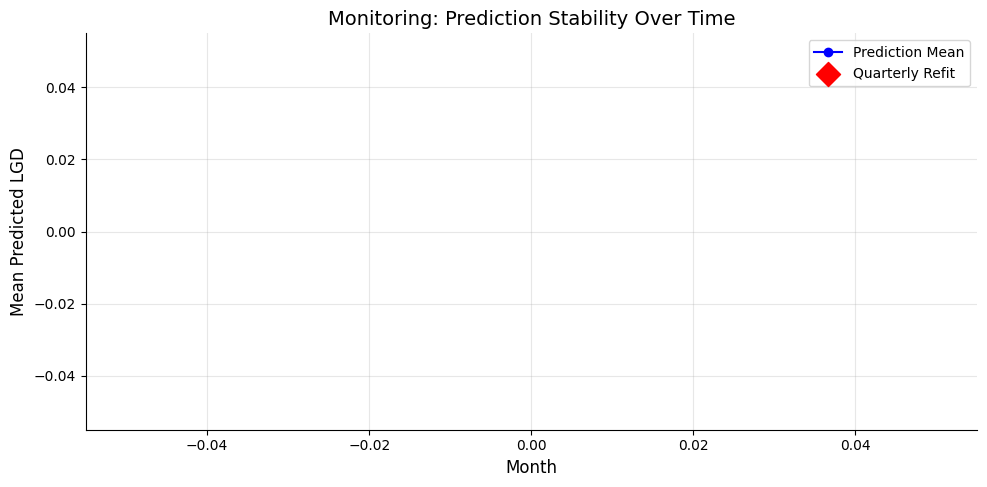

Figure saved.


In [20]:
# Visualize monitoring: prediction mean over time + refit points
fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(df_monitor["month"], df_monitor["pred_mean"], "b-o", label="Prediction Mean")

# Mark refit months
refit_months = df_monitor[df_monitor["refit"]]
ax.scatter(
    refit_months["month"],
    refit_months["pred_mean"],
    s=150,
    color="red",
    zorder=5,
    marker="D",
    label="Quarterly Refit",
)

# Annotate drift values
for _, row in refit_months.iterrows():
    if np.isfinite(row["max_drift"]):
        ax.annotate(
            f"{row['max_drift']:.1f}% drift",
            xy=(row["month"], row["pred_mean"]),
            xytext=(10, 15),
            textcoords="offset points",
            fontsize=9,
            ha="left",
            arrowprops={"arrowstyle": "->", "color": "gray"},
        )

ax.set_xlabel("Month")
ax.set_ylabel("Mean Predicted LGD")
ax.set_title("Monitoring: Prediction Stability Over Time")
ax.legend()
plt.tight_layout()
plt.savefig(FIGURES_DIR / "05_monitoring_workflow.png", dpi=300, bbox_inches="tight")
plt.show()
print("Figure saved.")

---

## Section 5: Managing the Registry

Over time, registries accumulate many versions. Good hygiene includes:
- Listing versions to review what's stored
- Deleting outdated versions to save disk space
- Verifying that the latest pointer is correct after deletion

In [21]:
# List all versions in the firm investment registry
print("Firm Investment Registry:")
print("=" * 50)
for v in registry.list_versions():
    print(f"  {v['version']}: {v['notes']}")

print(f"\nTotal: {len(registry.list_versions())} versions")

Firm Investment Registry:
  v1: Initial model on 2000-2015 data
  v2: Updated with 2016-2017 data
  v3: Full dataset 2000-2019

Total: 3 versions


In [22]:
# Delete the oldest version (v1)
print("Deleting v1...")
registry.delete_version("v1")

# Verify
remaining = registry.list_versions()
print(f"Versions remaining: {len(remaining)}")
for v in remaining:
    print(f"  {v['version']}: {v['notes']}")

# Latest should now be v3
latest = registry.load_latest()
print(f"\nLatest version loads correctly: {latest}")

Deleting v1...
Versions remaining: 2
  v2: Updated with 2016-2017 data
  v3: Full dataset 2000-2019

Latest version loads correctly: PanelPipeline(name='Firm Investment OLS', model=PooledOLS, fitted)


In [23]:
# Verify that deleted version cannot be loaded
try:
    registry.load_version("v1")
    print("ERROR: v1 should not exist!")
except FileNotFoundError as e:
    print(f"Correctly raised error: {e}")

Correctly raised error: Version 'v1' not found at ../outputs/registry/firm_investment/v1/model.pkl


In [24]:
# Show directory structure after deletion
import os

print(f"Registry directory: {firm_reg_dir}")
for root, _dirs, files in os.walk(firm_reg_dir):
    level = root.replace(str(firm_reg_dir), "").count(os.sep)
    indent = "  " * level
    print(f"{indent}{os.path.basename(root)}/")
    sub_indent = "  " * (level + 1)
    for file in files:
        filepath = Path(root) / file
        size_kb = filepath.stat().st_size / 1024
        print(f"{sub_indent}{file} ({size_kb:.1f} KB)")

Registry directory: ../outputs/registry/firm_investment
firm_investment/
  registry.json (0.5 KB)
  v2/
    metadata.json (0.2 KB)
    model.pkl (224.6 KB)
  v3/
    metadata.json (0.2 KB)
    model.pkl (249.0 KB)


---

## Exercises

### Exercise 1 (Easy): Create a Registry with 3 Versions

**Task**: Create a registry with 3 versions of a `PooledOLS` model, each trained on expanding time windows:
1. `v1`: Firm data 2000-2010
2. `v2`: Firm data 2000-2015
3. `v3`: Firm data 2000-2019

Use formula: `investment ~ value + capital + sales`

After registering all three, list the versions and load the latest one. Print its coefficients.

**Hint**: Use `df_firms[df_firms['year'] <= year_cutoff]` to filter the data.

In [25]:
# Exercise 1: Your code here


### Exercise 2 (Medium): Implement a Drift Detection Function

**Task**: Write a function `detect_drift(registry, threshold=10)` that:
1. Loads the two most recent versions from the registry
2. Compares them using `.compare()`
3. Returns a dictionary with:
   - `'drifted_params'`: list of parameter names where `|pct_change|` > threshold
   - `'max_drift'`: maximum absolute percentage change
   - `'stable'`: `True` if no parameter exceeds the threshold
   - `'comparison'`: the full comparison DataFrame

Test it on the firm investment registry.

**Hint**: Use `registry.list_versions()` to get the last two version names, then `registry.load_version()` to load them.

In [26]:
# Exercise 2: Your code here


### Exercise 3 (Hard): Automated Refit-and-Version Workflow

**Task**: Build a complete automated refit workflow:

1. Start with bank LGD data months 1-10
2. Each additional month (11, 12, 13, 14, 15), refit the model on all data up to that month
3. Compare with the previous version — register a new version only if drift > 15%
4. Track the coefficient values for each registered version
5. Plot the coefficient evolution across all registered versions
6. Create a summary table showing: version, month range, number of observations, and each coefficient value

Use the `DifferenceGMM` model with:
- `dep_var='lgd_logit'`, `lags=1`
- `exog_vars=['saldo_real', 'pib_growth', 'selic']`
- `collapse=True`, `two_step=False`, `time_dummies=False`

**Hint**: Keep a list of dicts `{'version': ..., 'params': ...}` to feed into `plot_coefficient_drift()`.

In [27]:
# Exercise 3: Your code here


---

## Summary

In this notebook, we learned:

- **`ModelRegistry`** provides simple, file-based model versioning with `register()`, `load_version()`, `load_latest()`, and `delete_version()`
- **Version metadata** includes timestamps, model class, observation count, and user notes
- **`pipeline.compare()`** detects parameter drift by computing coefficient differences and percentage changes
- **Monitoring workflows** combine periodic refit, drift detection, and conditional version registration
- **Registry management** includes listing, deleting old versions, and verifying the latest pointer
- A drift threshold (e.g., 10-20%) determines when a new version should be promoted to production

### Key Takeaways

1. Always version your models — you need an audit trail for regulatory compliance and debugging
2. Compare coefficients after every refit to detect unexpected changes
3. Set a drift threshold appropriate for your domain (finance: lower, marketing: higher)
4. Clean up old versions periodically to manage disk space
5. The registry pattern works for any PanelBox model (static or GMM)

### Next Steps

- **Notebook 06**: End-to-end case study putting all production concepts together